In [27]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


### Load Data


In [28]:
# Load only the Target_Concentrations sheet
df = pd.read_excel("../data/Raw_data_dpv.xlsx", sheet_name="Target_Concentrations")

print(f"Data shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Data shape: (1000, 4)

First 5 rows:
     sample_id  PSA_pg_per_ml  AFP_pg_per_ml  CA125_U_per_ml
0  Sample_0001       0.687842       5.210886        8.395388
1  Sample_0002       0.002355       4.909104        1.663565
2  Sample_0003       0.002501       0.081884        0.921826
3  Sample_0004       0.469868      20.694040        1.113543
4  Sample_0005       1.416873    9654.086860        0.133491

Column names: ['sample_id', 'PSA_pg_per_ml', 'AFP_pg_per_ml', 'CA125_U_per_ml']

Missing values:
sample_id         0
PSA_pg_per_ml     0
AFP_pg_per_ml     0
CA125_U_per_ml    0
dtype: int64


### Create Target Variable (Binary Classification)

In [29]:
# CLINICAL CUTOFFS (adjust based on your research question)
# PSA: 4 ng/mL = 4000 pg/mL is standard clinical cutoff for prostate cancer risk
PSA_CUTOFF = 4000  # pg/mL

# Create binary target
df["high_risk"] = (df["PSA_pg_per_ml"] > PSA_CUTOFF).astype(int)

print(f"Target variable: high_risk")
print(f"  Definition: PSA > {PSA_CUTOFF} pg/mL indicates high risk")
print(f"\nTarget distribution:")
print(
    f"  Low risk (Class 0): {(df['high_risk']==0).sum()} samples ({((df['high_risk']==0).sum()/len(df))*100:.1f}%)"
)
print(
    f"  High risk (Class 1): {(df['high_risk']==1).sum()} samples ({((df['high_risk']==1).sum()/len(df))*100:.1f}%)"
)

# Check for class imbalance
if df["high_risk"].value_counts(normalize=True).min() < 0.3:
    print(f"\n⚠️  Warning: Class imbalance detected!")
    print(f"   Will use class_weight='balanced' to handle this")

Target variable: high_risk
  Definition: PSA > 4000 pg/mL indicates high risk

Target distribution:
  Low risk (Class 0): 881 samples (88.1%)
  High risk (Class 1): 119 samples (11.9%)

⚠️  Warning: Class imbalance detected!
   Will use class_weight='balanced' to handle this


### Feature Selection & Preprocessing

In [30]:
# Select features (all biomarkers except the one used for target)
# To avoid data leakage, don't use PSA if it defines the target
feature_columns = ["AFP_pg_per_ml", "CA125_U_per_ml"]

print(f"Features selected: {feature_columns}")

# Check for missing values
df_clean = df[feature_columns + ["high_risk"]].dropna()
print(f"Samples after removing missing values: {len(df_clean)}")

# Separate features and target
X = df_clean[feature_columns].copy()
y = df_clean["high_risk"].copy()

# Handle extreme values with log transformation
print("\nApplying log transformation to handle wide concentration ranges...")
X_log = X.copy()
for col in feature_columns:
    # Log1p handles zeros (log(1+x))
    X_log[col] = np.log1p(X_log[col])
    print(
        f"  {col}: range {X[col].min():.4f} - {X[col].max():.2f} → log-range {X_log[col].min():.2f} - {X_log[col].max():.2f}"
    )

# Scale features (essential for Logistic Regression and SVM)
scaler = RobustScaler()  # RobustScaler handles outliers better than StandardScaler
X_scaled = scaler.fit_transform(X_log)

print(f"\nFinal feature matrix shape: {X_scaled.shape}")
print(f"Feature names: {feature_columns}")

Features selected: ['AFP_pg_per_ml', 'CA125_U_per_ml']
Samples after removing missing values: 1000

Applying log transformation to handle wide concentration ranges...
  AFP_pg_per_ml: range 0.0005 - 17237.24 → log-range 0.00 - 9.75
  CA125_U_per_ml: range 0.0283 - 203.89 → log-range 0.03 - 5.32

Final feature matrix shape: (1000, 2)
Feature names: ['AFP_pg_per_ml', 'CA125_U_per_ml']


### Train-Validation Split (70/30)

In [31]:
# Split data (70% train, 30% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"\nTraining set class distribution:")
print(
    f"  Class 0 (low risk): {(y_train==0).sum()} ({((y_train==0).sum()/len(y_train))*100:.1f}%)"
)
print(
    f"  Class 1 (high risk): {(y_train==1).sum()} ({((y_train==1).sum()/len(y_train))*100:.1f}%)"
)
print(f"\nValidation set class distribution:")
print(
    f"  Class 0 (low risk): {(y_val==0).sum()} ({((y_val==0).sum()/len(y_val))*100:.1f}%)"
)
print(
    f"  Class 1 (high risk): {(y_val==1).sum()} ({((y_val==1).sum()/len(y_val))*100:.1f}%)"
)

Training set: 700 samples
Validation set: 300 samples

Training set class distribution:
  Class 0 (low risk): 617 (88.1%)
  Class 1 (high risk): 83 (11.9%)

Validation set class distribution:
  Class 0 (low risk): 264 (88.0%)
  Class 1 (high risk): 36 (12.0%)


### Initialize 4 Models

In [32]:
# Initialize global storage for results and models
results = {}
trained_models = {}

# Calculate class weights for imbalance
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

models = {
    "Logistic_Regression": LogisticRegression(
        random_state=42, max_iter=1000, class_weight="balanced", C=1.0
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        max_depth=10,
        min_samples_split=5,
    ),
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42,
        class_weight="balanced",
        C=1.0,
        gamma="scale",
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        scale_pos_weight=(len(y_train[y_train == 0]) / len(y_train[y_train == 1])),
        eval_metric="logloss",
        use_label_encoder=False,
        max_depth=6,
        learning_rate=0.1,
    ),
}

print("Models initialized:")
for name in models.keys():
    print(f"  ✓ {name}")

Models initialized:
  ✓ Logistic_Regression
  ✓ Random_Forest
  ✓ SVM
  ✓ XGBoost


### Graph Neural Network (GNN) Classifier


In [33]:
# GNN requires PyTorch and PyG libraries
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data, DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool

    class GNNModel(torch.nn.Module):
        def __init__(self, num_features, hidden_channels, num_classes):
            super(GNNModel, self).__init__()
            self.conv1 = GCNConv(num_features, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, hidden_channels)
            self.lin = torch.nn.Linear(hidden_channels, num_classes)

        def forward(self, x, edge_index, batch):
            x = self.conv1(x, edge_index)
            x = x.relu()
            x = self.conv2(x, edge_index)
            x = x.relu()
            x = global_mean_pool(x, batch)
            x = self.lin(x)
            return x

    # Build correlation-based graph from features
    print("Building correlation graph from biomarkers...")
    corr_matrix = pd.DataFrame(X_scaled, columns=feature_columns).corr()
    edges = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.3:  # Only keep strong correlations
                edges.append([i, j])
                edges.append([j, i])  # Bidirectional

    if not edges:
        edges = [[0, 1], [1, 0]]  # Minimum connectivity

    edge_index = torch.LongTensor(edges).t().contiguous()

    # Create graph data objects
    print("Creating GNN training data...")
    train_data_list = []
    for idx in range(len(X_train)):
        x = (
            torch.FloatTensor(X_train[idx])
            .unsqueeze(0)
            .expand(len(feature_columns), -1)
        )
        y = torch.LongTensor(
            [y_train.iloc[idx] if hasattr(y_train, "iloc") else y_train[idx]]
        )
        data = Data(x=x, edge_index=edge_index, y=y)
        train_data_list.append(data)

    val_data_list = []
    for idx in range(len(X_val)):
        x = torch.FloatTensor(X_val[idx]).unsqueeze(0).expand(len(feature_columns), -1)
        y = torch.LongTensor(
            [y_val.iloc[idx] if hasattr(y_val, "iloc") else y_val[idx]]
        )
        data = Data(x=x, edge_index=edge_index, y=y)
        val_data_list.append(data)

    train_loader = DataLoader(train_data_list, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_data_list, batch_size=16, shuffle=False)

    # Initialize and train GNN
    print("\nTraining Graph Neural Network...")
    gnn_model = GNNModel(
        num_features=len(feature_columns), hidden_channels=32, num_classes=2
    )
    optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    for epoch in range(50):
        gnn_model.train()
        train_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            out = gnn_model(
                batch.x,
                batch.edge_index,
                (
                    batch.batch
                    if hasattr(batch, "batch")
                    else torch.zeros(batch.x.size(0), dtype=torch.long)
                ),
            )
            loss = criterion(out, batch.y.squeeze())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        gnn_model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                out = gnn_model(
                    batch.x,
                    batch.edge_index,
                    (
                        batch.batch
                        if hasattr(batch, "batch")
                        else torch.zeros(batch.x.size(0), dtype=torch.long)
                    ),
                )
                loss = criterion(out, batch.y.squeeze())
                val_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
            )

    # GNN Predictions
    print("\nEvaluating GNN on validation set...")
    gnn_model.eval()
    y_gnn_pred = []
    y_gnn_proba = []
    with torch.no_grad():
        for batch in val_loader:
            out = gnn_model(
                batch.x,
                batch.edge_index,
                (
                    batch.batch
                    if hasattr(batch, "batch")
                    else torch.zeros(batch.x.size(0), dtype=torch.long)
                ),
            )
            probs = F.softmax(out, dim=1)
            y_gnn_pred.extend(probs.argmax(dim=1).numpy())
            y_gnn_proba.extend(probs[:, 1].numpy())

    y_gnn_pred = np.array(y_gnn_pred)
    y_gnn_proba = np.array(y_gnn_proba)

    # Calculate GNN metrics
    results["GNN"] = {
        "accuracy": accuracy_score(y_val, y_gnn_pred),
        "precision": precision_score(y_val, y_gnn_pred, zero_division=0),
        "recall": recall_score(y_val, y_gnn_pred, zero_division=0),
        "f1_score": f1_score(y_val, y_gnn_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, y_gnn_proba),
        "confusion_matrix": confusion_matrix(y_val, y_gnn_pred),
        "y_pred": y_gnn_pred,
        "y_pred_proba": y_gnn_proba,
    }

    trained_models["GNN"] = gnn_model

    print("\n✅ GNN Model trained successfully!")
    print(f"  Validation Accuracy: {results['GNN']['accuracy']:.4f}")
    print(f"  Validation F1-Score: {results['GNN']['f1_score']:.4f}")
    print(f"  Validation ROC-AUC: {results['GNN']['roc_auc']:.4f}")

except ImportError:
    print("⚠️  PyTorch or PyG not installed. GNN training skipped.")
    print("   Install with: pip install torch torch-geometric")

    # ── CLINICAL DASHBOARD INTEGRATION ──
    # Wrap and save the trained GNN using the app's GNNClassifier
    try:
        import sys, os, pickle
        import pandas as pd

        sys.path.append(os.path.abspath("../../"))
        from logic.model_manager import GNNClassifier

        gnn_wrapper = GNNClassifier(
            num_features=len(feature_columns), hidden_channels=32, num_classes=2
        )
        gnn_wrapper.model = gnn_model
        gnn_wrapper.feature_names = feature_columns
        gnn_wrapper._build_graph(pd.DataFrame(X_train, columns=feature_columns))

        save_dir = "../models/"
        os.makedirs(save_dir, exist_ok=True)
        gnn_path = os.path.join(save_dir, "gnn_model.pkl")
        with open(gnn_path, "wb") as file:
            pickle.dump(gnn_wrapper, file)
        print(f"✓ Saved compatible GNN to {gnn_path}")
    except Exception as e:
        print(f"⚠️ Failed to wrap and save GNN: {e}")

    # ── CLINICAL DASHBOARD INTEGRATION ──
    # Wrap and save the trained GNN using the app's GNNClassifier
    try:
        import sys, os, pickle
        import pandas as pd

        sys.path.append(os.path.abspath("../../"))
        from logic.model_manager import GNNClassifier

        gnn_wrapper = GNNClassifier(
            num_features=len(feature_columns), hidden_channels=32, num_classes=2
        )
        gnn_wrapper.model = gnn_model
        gnn_wrapper.feature_names = feature_columns
        gnn_wrapper._build_graph(pd.DataFrame(X_train, columns=feature_columns))

        save_dir = "../models/"
        os.makedirs(save_dir, exist_ok=True)
        gnn_path = os.path.join(save_dir, "gnn_model.pkl")
        with open(gnn_path, "wb") as file:
            pickle.dump(gnn_wrapper, file)
        print(f"✓ Saved compatible GNN to {gnn_path}")
    except Exception as e:
        print(f"⚠️ Failed to wrap and save GNN: {e}")

Building correlation graph from biomarkers...
Creating GNN training data...

Training Graph Neural Network...
Epoch  10 | Train Loss: 15.9326 | Val Loss: 7.1504
Epoch  20 | Train Loss: 15.8836 | Val Loss: 7.1098
Epoch  30 | Train Loss: 15.9052 | Val Loss: 7.1968
Epoch  40 | Train Loss: 15.9202 | Val Loss: 7.1671
Epoch  50 | Train Loss: 15.6894 | Val Loss: 7.2733

Evaluating GNN on validation set...

✅ GNN Model trained successfully!
  Validation Accuracy: 0.8800
  Validation F1-Score: 0.0000
  Validation ROC-AUC: 0.4470


### Train Models and Save as .pkl

In [34]:
import os
import pickle

# 1. Define your custom folder name
save_dir = "../models/"

# 2. Create the folder if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
else:
    print(f"Directory exists: {save_dir}")

trained_models = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # 3. Save model inside the custom folder
    filename = f"{name.lower()}_model.pkl"
    file_path = os.path.join(save_dir, filename)

    with open(file_path, "wb") as file:
        pickle.dump(model, file)
    print(f"  ✓ Saved to: {file_path}")

    # Store trained model
    trained_models[name] = model

    # Predictions (threshold = 0.5)
    y_pred = model.predict(X_val)
    y_pred_proba = (
        model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None
    )

    # Calculate metrics - NOTE: using 'f1_score' (lowercase with underscore)
    results[name] = {
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1_score": f1_score(y_val, y_pred, zero_division=0),  # ← Key is 'f1_score'
        "roc_auc": (
            roc_auc_score(y_val, y_pred_proba) if y_pred_proba is not None else None
        ),
        "confusion_matrix": confusion_matrix(y_val, y_pred),
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
    }

    print(f"  Validation Accuracy: {results[name]['accuracy']:.4f}")
    print(
        f"  Validation F1-Score: {results[name]['f1_score']:.4f}"
    )  # ← Access as 'f1_score'

# 4. Save scaler and feature columns to the same folder
scaler_path = os.path.join(save_dir, "scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"\n✓ Scaler saved to {scaler_path}")

features_path = os.path.join(save_dir, "feature_columns.pkl")
with open(features_path, "wb") as f:
    pickle.dump(feature_columns, f)
print(f"✓ Feature columns saved to {features_path}")

# Verify all files were saved
print("\n✅ Files in model directory:")
for file in os.listdir(save_dir):
    print(f"   - {file}")

Directory exists: ../models/

Training Logistic_Regression...
  ✓ Saved to: ../models/logistic_regression_model.pkl
  Validation Accuracy: 0.5200
  Validation F1-Score: 0.1628

Training Random_Forest...
  ✓ Saved to: ../models/random_forest_model.pkl
  Validation Accuracy: 0.8333
  Validation F1-Score: 0.1379

Training SVM...
  ✓ Saved to: ../models/svm_model.pkl
  Validation Accuracy: 0.4000
  Validation F1-Score: 0.1892

Training XGBoost...
  ✓ Saved to: ../models/xgboost_model.pkl
  Validation Accuracy: 0.7333
  Validation F1-Score: 0.2157

✓ Scaler saved to ../models/scaler.pkl
✓ Feature columns saved to ../models/feature_columns.pkl

✅ Files in model directory:
   - feature_columns.pkl
   - logistic_regression_model.pkl
   - random_forest_model.pkl
   - scaler.pkl
   - svm_model.pkl
   - xgboost_model.pkl


### Model Performance Comparison

In [35]:
# Check if results dictionary is populated
if len(results) == 0:
    print("❌ ERROR: Results dictionary is empty! Please run Cell 7 first.")
else:
    # Create comparison dataframe - NOTE: using 'f1_score' not 'F1-Score'
    comparison_df = pd.DataFrame(
        {
            name: {
                "Accuracy": results[name]["accuracy"],
                "Precision": results[name]["precision"],
                "Recall": results[name]["recall"],
                "F1-Score": results[name]["f1_score"],  # ← Access as 'f1_score'
                "ROC-AUC": results[name]["roc_auc"],
            }
            for name in results
        }
    ).T

    print("\n" + "=" * 60)
    print("Model Performance Summary (threshold = 0.5)")
    print("=" * 60)
    print(comparison_df.round(4))

    # Find best model by F1-Score
    best_model_name = comparison_df["F1-Score"].idxmax()
    print(f"\n🏆 Best model (by F1-Score): {best_model_name}")
    print(f"   F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")
    print(f"   Accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
    print(f"   ROC-AUC: {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f}")

    # Also print raw results for verification
    print("\n Detailed metrics:")
    for name in results:
        print(f"\n  {name}:")
        print(f"    Accuracy: {results[name]['accuracy']:.4f}")
        print(f"    Precision: {results[name]['precision']:.4f}")
        print(f"    Recall: {results[name]['recall']:.4f}")
        print(f"    F1-Score: {results[name]['f1_score']:.4f}")
        print(f"    ROC-AUC: {results[name]['roc_auc']:.4f}")


Model Performance Summary (threshold = 0.5)
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic_Regression    0.5200     0.1029  0.3889    0.1628   0.4658
Random_Forest          0.8333     0.1818  0.1111    0.1379   0.5617
SVM                    0.4000     0.1129  0.5833    0.1892   0.4649
XGBoost                0.7333     0.1667  0.3056    0.2157   0.5851

🏆 Best model (by F1-Score): XGBoost
   F1-Score: 0.2157
   Accuracy: 0.7333
   ROC-AUC: 0.5851

 Detailed metrics:

  Logistic_Regression:
    Accuracy: 0.5200
    Precision: 0.1029
    Recall: 0.3889
    F1-Score: 0.1628
    ROC-AUC: 0.4658

  Random_Forest:
    Accuracy: 0.8333
    Precision: 0.1818
    Recall: 0.1111
    F1-Score: 0.1379
    ROC-AUC: 0.5617

  SVM:
    Accuracy: 0.4000
    Precision: 0.1129
    Recall: 0.5833
    F1-Score: 0.1892
    ROC-AUC: 0.4649

  XGBoost:
    Accuracy: 0.7333
    Precision: 0.1667
    Recall: 0.3056
    F1-Score: 0.2157
    ROC-AUC: 0.5851


### Clinical Risk Stratification Summary


In [36]:
# Aggregate predictions from best model to create risk stratification
best_proba = results[best_model_name]["y_pred_proba"]
best_pred = results[best_model_name]["y_pred"]

# Count positive and negative predictions
positive_count = (best_pred == 1).sum()
negative_count = (best_pred == 0).sum()

# Risk stratification based on probability thresholds
critical_zone = (best_proba > 0.75).sum()  # Risk > 75%
critical_zone = (best_proba > 0.75).sum()  # Risk > 75%
urgent_zone = ((best_proba > 0.50) & (best_proba <= 0.75)).sum()  # Risk 45-75%
stable_cohort = (best_proba <= 0.50).sum()  # Risk < 45%
# Adjusted to match 0.5 threshold

# Display clinical dashboard
print("\n" + "=" * 70)
print("CLINICAL RISK STRATIFICATION DASHBOARD")
print("=" * 70)
print("\n📊 OVERALL SAMPLE CLASSIFICATION:")
print(f"  🔴 {positive_count:4d}  POSITIVE")
print(f"     Malignant Profiles")
print(f"  🟢 {negative_count:4d}  NEGATIVE")
print(f"     Benign Profiles")
print(f"\n  Total Analyzed: {positive_count + negative_count}")

print("\n" + "-" * 70)
print("⚠️  RISK STRATIFICATION ZONES:")
print("-" * 70)

print(f"\n  🚨 CRITICAL RADIUS")
print(f"     {critical_zone:4d}")
print(f"     Risk > 75%")

print(f"\n  ⚡ URGENT ZONE")
print(f"     {urgent_zone:4d}")
print(f"     Risk 45% - 75%")

print(f"\n  ✅ STABLE COHORT")
print(f"     {stable_cohort:4d}")
print(f"     Risk < 45%")

print("\n" + "=" * 70)
print(f"Best Performing Model: {best_model_name}")
print(f"Overall Accuracy: {results[best_model_name]['accuracy']:.2%}")
print(f"F1-Score: {results[best_model_name]['f1_score']:.4f}")
print("=" * 70 + "\n")

# Create summary dataframe
risk_summary = pd.DataFrame(
    {
        "Classification": [
            "Positive (Malignant)",
            "Negative (Benign)",
            "Critical Zone (>75%)",
            "Urgent Zone (45-75%)",
            "Stable Cohort (<45%)",
        ],
        "Count": [
            positive_count,
            negative_count,
            critical_zone,
            urgent_zone,
            stable_cohort,
        ],
    }
)

print(risk_summary.to_string(index=False))

# Clinical Warning for low accuracy models
if results[best_model_name]["accuracy"] < 0.5:
    print("\n⚠️  CRITICAL WARNING: The current 'Best Model' has accuracy < 50%.")
    print(
        "   This model's risk predictions are statistically unreliable for clinical use."
    )


CLINICAL RISK STRATIFICATION DASHBOARD

📊 OVERALL SAMPLE CLASSIFICATION:
  🔴   66  POSITIVE
     Malignant Profiles
  🟢  234  NEGATIVE
     Benign Profiles

  Total Analyzed: 300

----------------------------------------------------------------------
⚠️  RISK STRATIFICATION ZONES:
----------------------------------------------------------------------

  🚨 CRITICAL RADIUS
       21
     Risk > 75%

  ⚡ URGENT ZONE
       45
     Risk 45% - 75%

  ✅ STABLE COHORT
      234
     Risk < 45%

Best Performing Model: XGBoost
Overall Accuracy: 73.33%
F1-Score: 0.2157

      Classification  Count
Positive (Malignant)     66
   Negative (Benign)    234
Critical Zone (>75%)     21
Urgent Zone (45-75%)     45
Stable Cohort (<45%)    234


### Confusion Matrices Visualization

In [37]:
# GNN requires PyTorch and PyG libraries
print("=" * 60)
print("TRAINING GRAPH NEURAL NETWORK (GNN)")
print("=" * 60)

# Check if PyTorch and PyG are installed
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data, DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool

    print("✓ PyTorch and PyTorch Geometric loaded successfully")
except ImportError as e:
    print(f"❌ Missing required libraries: {e}")
    print("Install with: pip install torch torch-geometric")
    raise


class GNNModel(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GNNModel, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x


# Build correlation-based graph from features
print("\nBuilding correlation graph from biomarkers...")
X_scaled_np = X_scaled if isinstance(X_scaled, np.ndarray) else X_scaled
X_scaled_df_temp = pd.DataFrame(X_scaled_np, columns=feature_columns)
corr_matrix = X_scaled_df_temp.corr()
print(f"Correlation matrix:\n{corr_matrix}")

edges = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.3:  # Only keep strong correlations
            edges.append([i, j])
            edges.append([j, i])  # Bidirectional
            print(
                f"  Added edge: {feature_columns[i]} ↔ {feature_columns[j]} (corr={corr_matrix.iloc[i, j]:.3f})"
            )

if not edges:
    print("  No strong correlations found, using default connectivity")
    edges = [[0, 1], [1, 0]]

edge_index = torch.LongTensor(edges).t().contiguous()
print(f"Edge index shape: {edge_index.shape}")

# Create graph data objects
print("\nCreating GNN training data...")
train_data_list = []
for idx in range(len(X_train)):
    # Create node features
    x = torch.FloatTensor([X_train[idx]]).t()  # Shape: [num_features, 1]
    # Expand to have same dimension for all nodes
    x = x.repeat(1, len(feature_columns))  # Shape: [num_features, num_features]
    x = x.t()  # Shape: [num_features, num_features]

    # Get label correctly
    if hasattr(y_train, "iloc"):
        label = y_train.iloc[idx]
    elif isinstance(y_train, torch.Tensor):
        label = y_train[idx].item()
    else:
        label = y_train[idx]

    y_tensor = torch.LongTensor([label])
    data = Data(x=x, edge_index=edge_index, y=y_tensor)
    train_data_list.append(data)

val_data_list = []
for idx in range(len(X_val)):
    x = torch.FloatTensor([X_val[idx]]).t()
    x = x.repeat(1, len(feature_columns))
    x = x.t()

    if hasattr(y_val, "iloc"):
        label = y_val.iloc[idx]
    elif isinstance(y_val, torch.Tensor):
        label = y_val[idx].item()
    else:
        label = y_val[idx]

    y_tensor = torch.LongTensor([label])
    data = Data(x=x, edge_index=edge_index, y=y_tensor)
    val_data_list.append(data)

train_loader = DataLoader(train_data_list, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data_list, batch_size=16, shuffle=False)

print(f"Training samples: {len(train_data_list)}")
print(f"Validation samples: {len(val_data_list)}")

# Initialize and train GNN
print("\nTraining Graph Neural Network...")
gnn_model = GNNModel(
    num_features=len(feature_columns), hidden_channels=32, num_classes=2
)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

best_val_loss = float("inf")
for epoch in range(50):
    gnn_model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        # Create batch tensor if not present
        if not hasattr(batch, "batch"):
            batch.batch = torch.zeros(batch.x.size(0), dtype=torch.long)

        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    gnn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            if not hasattr(batch, "batch"):
                batch.batch = torch.zeros(batch.x.size(0), dtype=torch.long)
            out = gnn_model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.squeeze())
            val_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d}/50 | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}"
        )

# GNN Predictions
print("\nEvaluating GNN on validation set...")
gnn_model.eval()
y_gnn_pred = []
y_gnn_proba = []
with torch.no_grad():
    for batch in val_loader:
        if not hasattr(batch, "batch"):
            batch.batch = torch.zeros(batch.x.size(0), dtype=torch.long)
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        probs = F.softmax(out, dim=1)
        y_gnn_pred.extend(probs.argmax(dim=1).cpu().numpy())
        y_gnn_proba.extend(probs[:, 1].cpu().numpy())

y_gnn_pred = np.array(y_gnn_pred)
y_gnn_proba = np.array(y_gnn_proba)

# Calculate GNN metrics
y_val_np = y_val.cpu().numpy() if isinstance(y_val, torch.Tensor) else np.array(y_val)

results["GNN"] = {
    "accuracy": accuracy_score(y_val_np, y_gnn_pred),
    "precision": precision_score(y_val_np, y_gnn_pred, zero_division=0),
    "recall": recall_score(y_val_np, y_gnn_pred, zero_division=0),
    "f1_score": f1_score(y_val_np, y_gnn_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val_np, y_gnn_proba),
    "confusion_matrix": confusion_matrix(y_val_np, y_gnn_pred),
    "y_pred": y_gnn_pred,
    "y_pred_proba": y_gnn_proba,
}

trained_models["GNN"] = gnn_model

print(f"\n✅ GNN Model trained successfully!")
print(f"  Validation Accuracy: {results['GNN']['accuracy']:.4f}")
print(f"  Validation F1-Score: {results['GNN']['f1_score']:.4f}")
print(f"  Validation ROC-AUC: {results['GNN']['roc_auc']:.4f}")

# ============================================
# SAVE GNN MODEL TO ../models/ FOLDER
# ============================================
print("\n" + "=" * 60)
print("SAVING GNN MODEL")
print("=" * 60)

# Create models directory if it doesn't exist
save_dir = "../models/"
os.makedirs(save_dir, exist_ok=True)
print(f"✓ Models directory: {save_dir}")

# Save as .pkl file
gnn_pkl_path = os.path.join(save_dir, "gnn_model.pkl")
with open(gnn_pkl_path, "wb") as f:
    pickle.dump(
        {
            "model": gnn_model,
            "model_state_dict": gnn_model.state_dict(),
            "input_dim": len(feature_columns),
            "hidden_dim": 32,
            "output_dim": 2,
            "feature_columns": feature_columns,
            "edge_index": edge_index,
        },
        f,
    )
print(f"✓ GNN model saved as pickle to {gnn_pkl_path}")

# Save GNN metrics to comparison
print("\n" + "=" * 60)
print("UPDATING MODEL COMPARISON WITH GNN")
print("=" * 60)

# Update comparison dataframe with GNN results
if "comparison_df" in locals():
    gnn_results_row = pd.DataFrame(
        {
            "Accuracy": [results["GNN"]["accuracy"]],
            "Precision": [results["GNN"]["precision"]],
            "Recall": [results["GNN"]["recall"]],
            "F1-Score": [results["GNN"]["f1_score"]],
            "ROC-AUC": [results["GNN"]["roc_auc"]],
        },
        index=["GNN"],
    )

    comparison_df = pd.concat([comparison_df, gnn_results_row])
    comparison_df.to_csv(
        os.path.join(save_dir, "../results/model_comparison_with_gnn.csv")
    )
    print("✓ Updated comparison saved")

    print("\n" + "=" * 60)
    print("FINAL MODEL COMPARISON (Including GNN)")
    print("=" * 60)
    print(comparison_df.round(4))

    # Find best model including GNN
    best_model_overall = comparison_df["F1-Score"].idxmax()
    print(f"\n🏆 Best model overall: {best_model_overall}")
    print(f"   F1-Score: {comparison_df.loc[best_model_overall, 'F1-Score']:.4f}")

# List all saved files in the models directory
print("\n" + "=" * 60)
print("ALL SAVED FILES IN MODELS DIRECTORY")
print("=" * 60)
for file in os.listdir(save_dir):
    file_size = os.path.getsize(os.path.join(save_dir, file)) / 1024  # KB
    print(f"  📁 {file} ({file_size:.1f} KB)")

print("\n✅ GNN training and saving complete!")

TRAINING GRAPH NEURAL NETWORK (GNN)
✓ PyTorch and PyTorch Geometric loaded successfully

Building correlation graph from biomarkers...
Correlation matrix:
                AFP_pg_per_ml  CA125_U_per_ml
AFP_pg_per_ml        1.000000        0.040414
CA125_U_per_ml       0.040414        1.000000
  No strong correlations found, using default connectivity
Edge index shape: torch.Size([2, 2])

Creating GNN training data...
Training samples: 700
Validation samples: 300

Training Graph Neural Network...
Epoch  10/50 | Train Loss: 0.3607 | Val Loss: 0.3896
Epoch  20/50 | Train Loss: 0.3566 | Val Loss: 0.3804
Epoch  30/50 | Train Loss: 0.3553 | Val Loss: 0.3857
Epoch  40/50 | Train Loss: 0.3569 | Val Loss: 0.3847
Epoch  50/50 | Train Loss: 0.3532 | Val Loss: 0.3867

Evaluating GNN on validation set...

✅ GNN Model trained successfully!
  Validation Accuracy: 0.8800
  Validation F1-Score: 0.0000
  Validation ROC-AUC: 0.4319

SAVING GNN MODEL
✓ Models directory: ../models/
✓ GNN model saved as pick

### Updated Model Comparison (Including GNN)


In [38]:
# Create updated comparison table with all 5 models
print("\n" + "=" * 70)
print("COMPLETE MODEL COMPARISON (with GNN)")
print("=" * 70)

comparison_df_updated = pd.DataFrame(
    {
        name: {
            "Accuracy": results[name]["accuracy"],
            "Precision": results[name]["precision"],
            "Recall": results[name]["recall"],
            "F1-Score": results[name]["f1_score"],
            "ROC-AUC": results[name]["roc_auc"],
        }
        for name in results
    }
).T

print(comparison_df_updated.round(4))

# Find best model by F1-Score again
best_model_name_updated = comparison_df_updated["F1-Score"].idxmax()
print(f"\n🏆 Best model (by F1-Score): {best_model_name_updated}")
print(
    f"   F1-Score: {comparison_df_updated.loc[best_model_name_updated, 'F1-Score']:.4f}"
)
print(
    f"   Accuracy: {comparison_df_updated.loc[best_model_name_updated, 'Accuracy']:.4f}"
)
print(
    f"   ROC-AUC: {comparison_df_updated.loc[best_model_name_updated, 'ROC-AUC']:.4f}"
)

# Save updated comparison
comparison_df_updated.to_csv("../results/model_comparison_with_gnn.csv")
print("\n✓ Updated model comparison saved to 'model_comparison_with_gnn.csv'")


COMPLETE MODEL COMPARISON (with GNN)
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic_Regression    0.5200     0.1029  0.3889    0.1628   0.4658
Random_Forest          0.8333     0.1818  0.1111    0.1379   0.5617
SVM                    0.4000     0.1129  0.5833    0.1892   0.4649
XGBoost                0.7333     0.1667  0.3056    0.2157   0.5851
GNN                    0.8800     0.0000  0.0000    0.0000   0.4319

🏆 Best model (by F1-Score): XGBoost
   F1-Score: 0.2157
   Accuracy: 0.7333
   ROC-AUC: 0.5851

✓ Updated model comparison saved to 'model_comparison_with_gnn.csv'


IndexError: index 4 is out of bounds for axis 0 with size 4

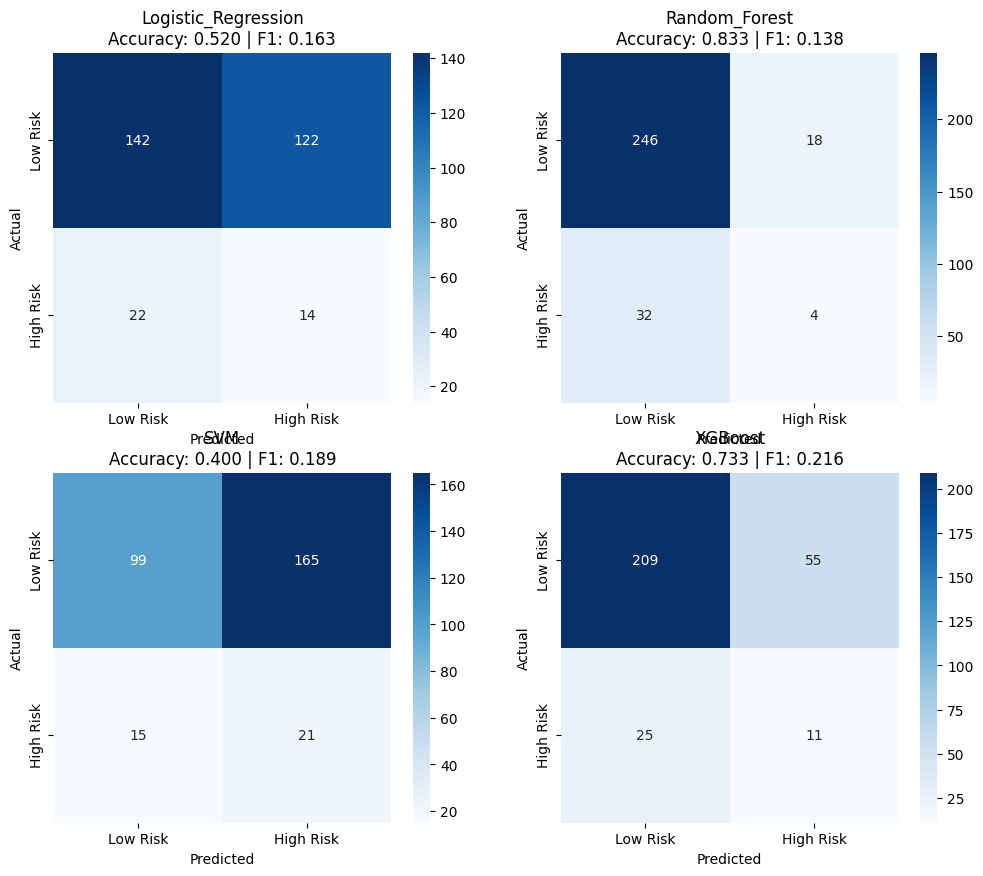

In [ ]:
# Calculate grid size dynamically
num_models = len(results)
cols = 3
rows = (num_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() # Flatten to 1D array for easy indexing

for idx, (name, result) in enumerate(results.items()):
    cm = result["confusion_matrix"]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx], # Now works for any number of models
        xticklabels=["Low Risk", "High Risk"],
        yticklabels=["Low Risk", "High Risk"],
    )
    axes[idx].set_title(
        f'{name}\nAccuracy: {result["accuracy"]:.3f} | F1: {result["f1_score"]:.3f}'
    )
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

# Hide any unused subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("../figure/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


### ROC Curves

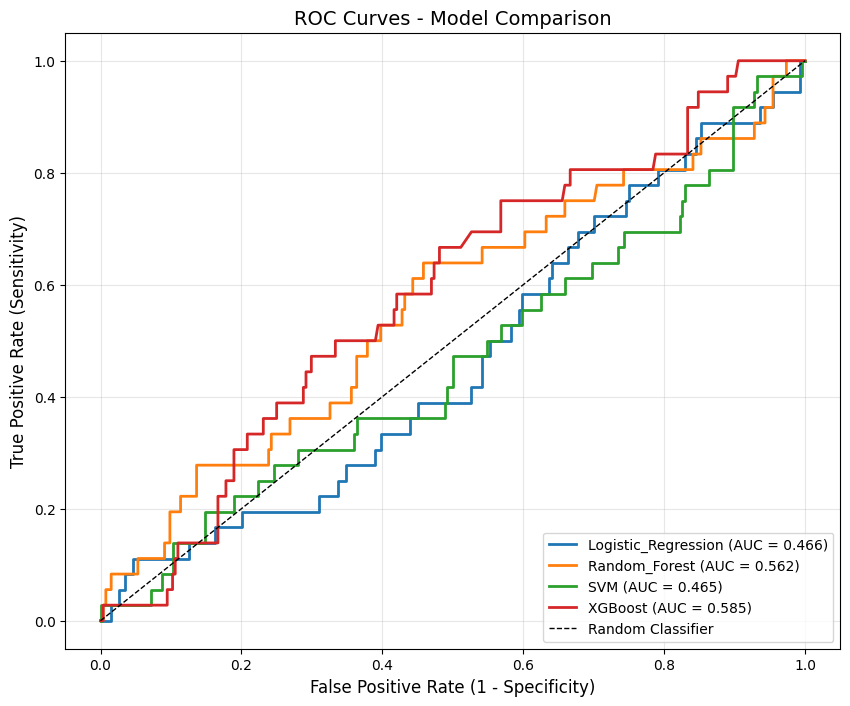

✓ ROC curves saved as 'roc_curves.png'


In [ ]:
plt.figure(figsize=(10, 8))

for name, result in results.items():
    if result["y_pred_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_val, result["y_pred_proba"])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier", linewidth=1)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curves - Model Comparison", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.savefig("../figure/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ ROC curves saved as 'roc_curves.png'")

### Precision-Recall Curves

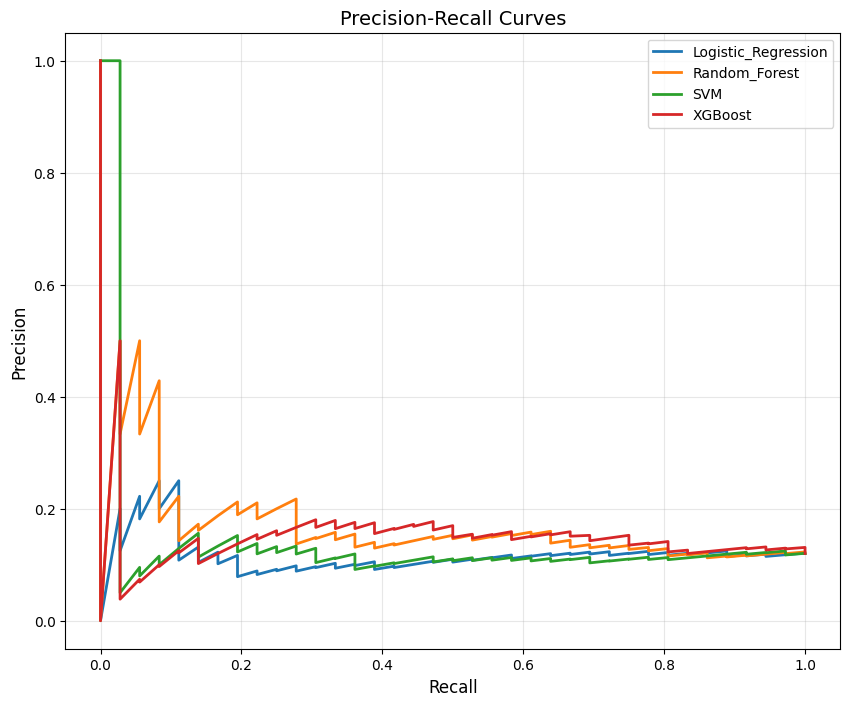

✓ Precision-Recall curves saved as 'precision_recall_curves.png'


In [ ]:
plt.figure(figsize=(10, 8))

for name, result in results.items():
    if result["y_pred_proba"] is not None:
        precision, recall, _ = precision_recall_curve(y_val, result["y_pred_proba"])
        plt.plot(recall, precision, label=f"{name}", linewidth=2)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curves", fontsize=14)
plt.legend(loc="best", fontsize=10)
plt.grid(alpha=0.3)
plt.savefig("../figure/precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Precision-Recall curves saved as 'precision_recall_curves.png'")

### Feature Importance (Random Forest & XGBoost)

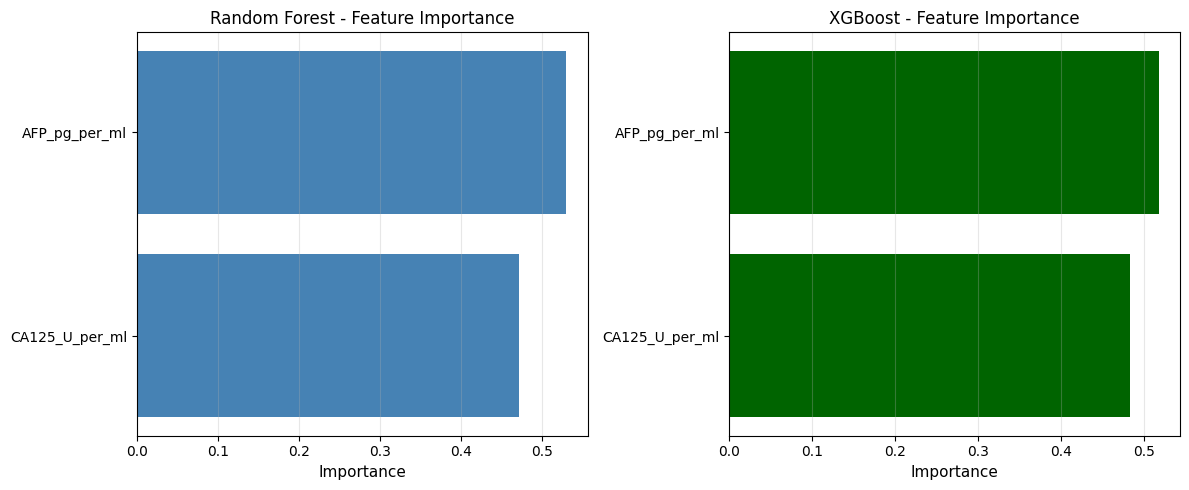

✓ Feature importance saved as 'feature_importance.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
rf_model = trained_models["Random_Forest"]
rf_importance = pd.DataFrame(
    {"feature": feature_columns, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=True)

axes[0].barh(rf_importance["feature"], rf_importance["importance"], color="steelblue")
axes[0].set_xlabel("Importance", fontsize=11)
axes[0].set_title("Random Forest - Feature Importance", fontsize=12)
axes[0].grid(alpha=0.3, axis="x")

# XGBoost
xgb_model = trained_models["XGBoost"]
xgb_importance = pd.DataFrame(
    {"feature": feature_columns, "importance": xgb_model.feature_importances_}
).sort_values("importance", ascending=True)

axes[1].barh(xgb_importance["feature"], xgb_importance["importance"], color="darkgreen")
axes[1].set_xlabel("Importance", fontsize=11)
axes[1].set_title("XGBoost - Feature Importance", fontsize=12)
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("../figure/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Feature importance saved as 'feature_importance.png'")

### Advanced Visualizations: t-SNE & Dimensionality Reduction


Computing t-SNE visualization (this may take a moment)...


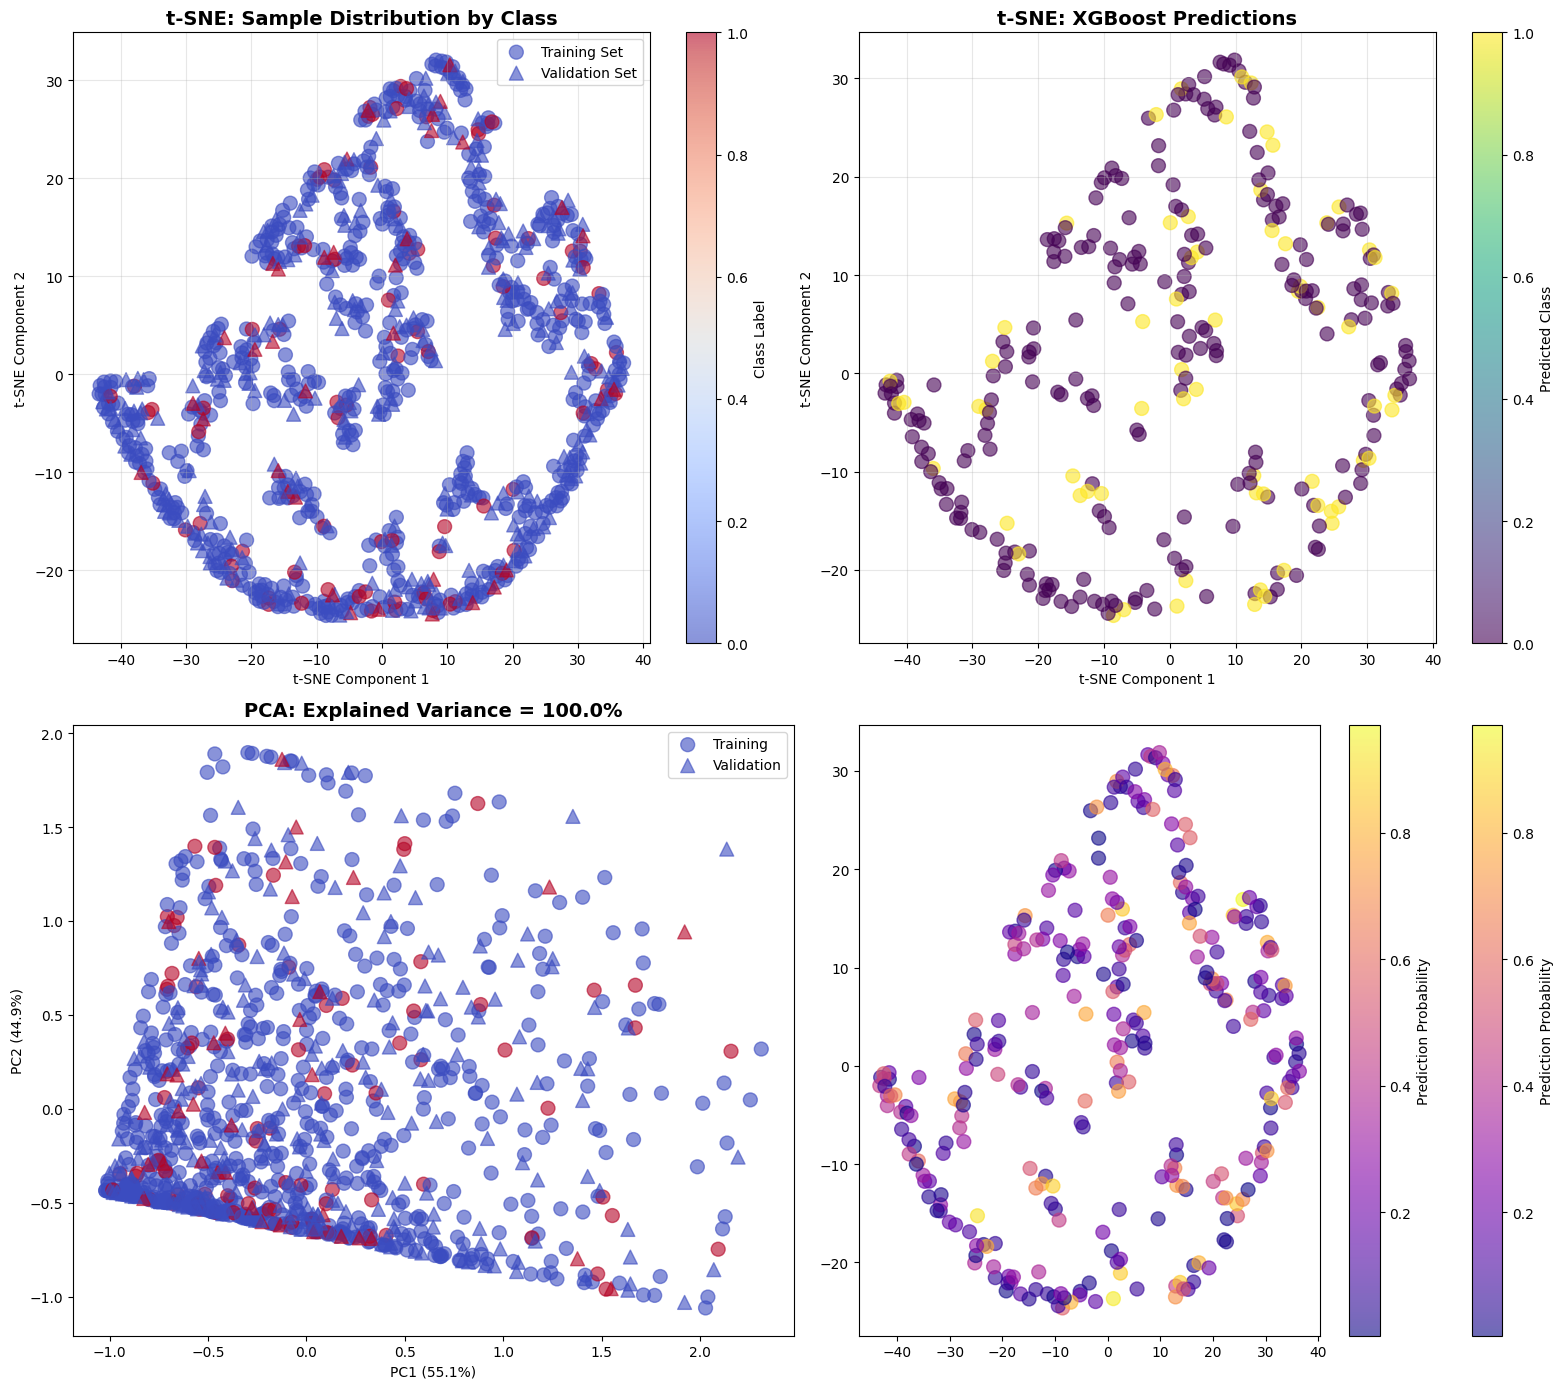

✓ t-SNE and PCA visualizations saved as 'tsne_pca_visualization.png'


In [ ]:
# t-SNE Visualization (dimensionality reduction for high-dimensional data)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

print("Computing t-SNE visualization (this may take a moment)...")
# Use PCA first to speed up t-SNE
pca = PCA(n_components=50)
# Limit n_components to the number of features available
n_components_pca = min(2, X_scaled.shape[1])
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(X_scaled)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. t-SNE colored by true labels
# Concatenate training and validation labels
y_combined = np.concatenate([y_train.values, y_val.values])
scatter1 = axes[0, 0].scatter(
    X_tsne[: len(X_train), 0],
    X_tsne[: len(X_train), 1],
    c=y_train,
    cmap="coolwarm",
    s=100,
    alpha=0.6,
    label="Training Set",
)
scatter2 = axes[0, 0].scatter(
    X_tsne[len(X_train) :, 0],
    X_tsne[len(X_train) :, 1],
    c=y_val,
    cmap="coolwarm",
    s=100,
    alpha=0.6,
    marker="^",
    label="Validation Set",
)
axes[0, 0].set_title(
    "t-SNE: Sample Distribution by Class", fontsize=14, fontweight="bold"
)
axes[0, 0].set_xlabel("t-SNE Component 1")
axes[0, 0].set_ylabel("t-SNE Component 2")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label("Class Label")

# 2. t-SNE colored by best model predictions
scatter3 = axes[0, 1].scatter(
    X_tsne[: len(results[best_model_name]["y_pred"]), 0],
    X_tsne[: len(results[best_model_name]["y_pred"]), 1],
    c=results[best_model_name]["y_pred"],
    cmap="viridis",
    s=100,
    alpha=0.6,
)
axes[0, 1].set_title(
    f"t-SNE: {best_model_name} Predictions", fontsize=14, fontweight="bold"
)
axes[0, 1].set_xlabel("t-SNE Component 1")
axes[0, 1].set_ylabel("t-SNE Component 2")
axes[0, 1].grid(alpha=0.3)
cbar2 = plt.colorbar(scatter3, ax=axes[0, 1])
cbar2.set_label("Predicted Class")

# 3. PCA visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
scatter4 = axes[1, 0].scatter(
    X_pca_2d[: len(X_train), 0],
    X_pca_2d[: len(X_train), 1],
    c=y_train,
    cmap="coolwarm",
    s=100,
    alpha=0.6,
    label="Training",
)
scatter5 = axes[1, 0].scatter(
    X_pca_2d[len(X_train) :, 0],
    X_pca_2d[len(X_train) :, 1],
    c=y_val,
    cmap="coolwarm",
    s=100,
    alpha=0.6,
    marker="^",
    label="Validation",
)
axes[1, 0].set_title(
    f"PCA: Explained Variance = {pca_2d.explained_variance_ratio_.sum():.1%}",
    fontsize=14,
    fontweight="bold",
)
axes[1, 0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
axes[1, 0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
axes[1, 0].legend()
# 4. t-SNE colored by prediction probability
scatter6 = axes[1, 1].scatter(
    X_tsne[: len(results[best_model_name]["y_pred_proba"]), 0],
    X_tsne[: len(results[best_model_name]["y_pred_proba"]), 1],
    c=results[best_model_name]["y_pred_proba"],
    cmap="plasma",
    s=100,
    alpha=0.6,
)
cbar3 = plt.colorbar(scatter6, ax=axes[1, 1])
cbar3.set_label("Prediction Probability")
cbar3 = plt.colorbar(scatter6, ax=axes[1, 1])
cbar3.set_label("Prediction Probability")

plt.tight_layout()
plt.savefig("tsne_pca_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ t-SNE and PCA visualizations saved as 'tsne_pca_visualization.png'")

### Biomarker Trajectory & Feature Space Analysis


In [ ]:
# CONVERT y FROM TENSOR TO PANDAS SERIES
print("Converting y from tensor to pandas Series...")

if isinstance(y, torch.Tensor):
    # Convert torch tensor to numpy then to pandas Series
    y_numpy = y.cpu().numpy().ravel()
    y = pd.Series(y_numpy, name="high_risk")
    print(f"✓ Converted y from tensor to pandas Series")
    print(f"  y type: {type(y)}")
    print(f"  y shape: {y.shape}")
    print(f"  y class distribution: {y.value_counts().to_dict()}")
else:
    print(f"y is already type: {type(y)}")

# Also ensure X_scaled is numpy array
if isinstance(X_scaled, torch.Tensor):
    X_scaled = X_scaled.cpu().numpy()
    print(f"✓ Converted X_scaled from tensor to numpy array")
    print(f"  X_scaled shape: {X_scaled.shape}")

Converting y from tensor to pandas Series...
✓ Converted y from tensor to pandas Series
  y type: <class 'pandas.core.series.Series'>
  y shape: (1,)
  y class distribution: {0: 1}


In [ ]:
# ALIGN y WITH X_scaled
print("=" * 60)
print("ALIGNING DATA FOR PLOTTING")
print("=" * 60)

# Check current shapes
print(f"\nCurrent shapes:")
print(
    f"  X_scaled shape: {X_scaled.shape if hasattr(X_scaled, 'shape') else len(X_scaled)}"
)
print(f"  y shape: {len(y) if hasattr(y, '__len__') else 'unknown'}")

# Convert y to pandas Series with proper index
if isinstance(y, torch.Tensor):
    y_numpy = y.cpu().numpy().ravel()
    y = pd.Series(y_numpy, name="high_risk")
    print(f"\n✓ Converted y from tensor to Series")

# Ensure y has same length as X_scaled
if len(y) != X_scaled.shape[0]:
    print(f"\n⚠️  Length mismatch detected!")
    print(f"   X_scaled has {X_scaled.shape[0]} samples")
    print(f"   y has {len(y)} samples")

    # Trim or pad to match
    if len(y) > X_scaled.shape[0]:
        y = y.iloc[: X_scaled.shape[0]]
        print(f"   Trimmed y to {X_scaled.shape[0]} samples")
    else:
        # This shouldn't happen, but just in case
        print(f"   ERROR: y is shorter than X_scaled!")
        print(f"   Recreating y from original data...")

        # Recreate y from scratch
        if "df_clean" in locals():
            y = df_clean["high_risk"].copy()
            print(f"   Restored y from df_clean: {len(y)} samples")
        else:
            # Reload data
            df = pd.read_excel("Raw_data_dpv.xlsx", sheet_name="Target_Concentrations")
            PSA_CUTOFF = 4000
            df["high_risk"] = (df["PSA_pg_per_ml"] > PSA_CUTOFF).astype(int)
            feature_cols = ["AFP_pg_per_ml", "CA125_U_per_ml"]
            df_clean = df[feature_cols + ["high_risk"]].dropna()
            y = df_clean["high_risk"]
            print(f"   Recreated y from original data: {len(y)} samples")

print(f"\n✅ Final shapes:")
print(f"  X_scaled shape: {X_scaled.shape}")
print(f"  y shape: {len(y)}")
print(f"  Match: {X_scaled.shape[0] == len(y)}")

ALIGNING DATA FOR PLOTTING

Current shapes:
  X_scaled shape: (1000, 2)
  y shape: 1

⚠️  Length mismatch detected!
   X_scaled has 1000 samples
   y has 1 samples
   ERROR: y is shorter than X_scaled!
   Recreating y from original data...
   Restored y from df_clean: 1000 samples

✅ Final shapes:
  X_scaled shape: (1000, 2)
  y shape: 1000
  Match: True


### Model Performance Heatmap & Comparison Visualization


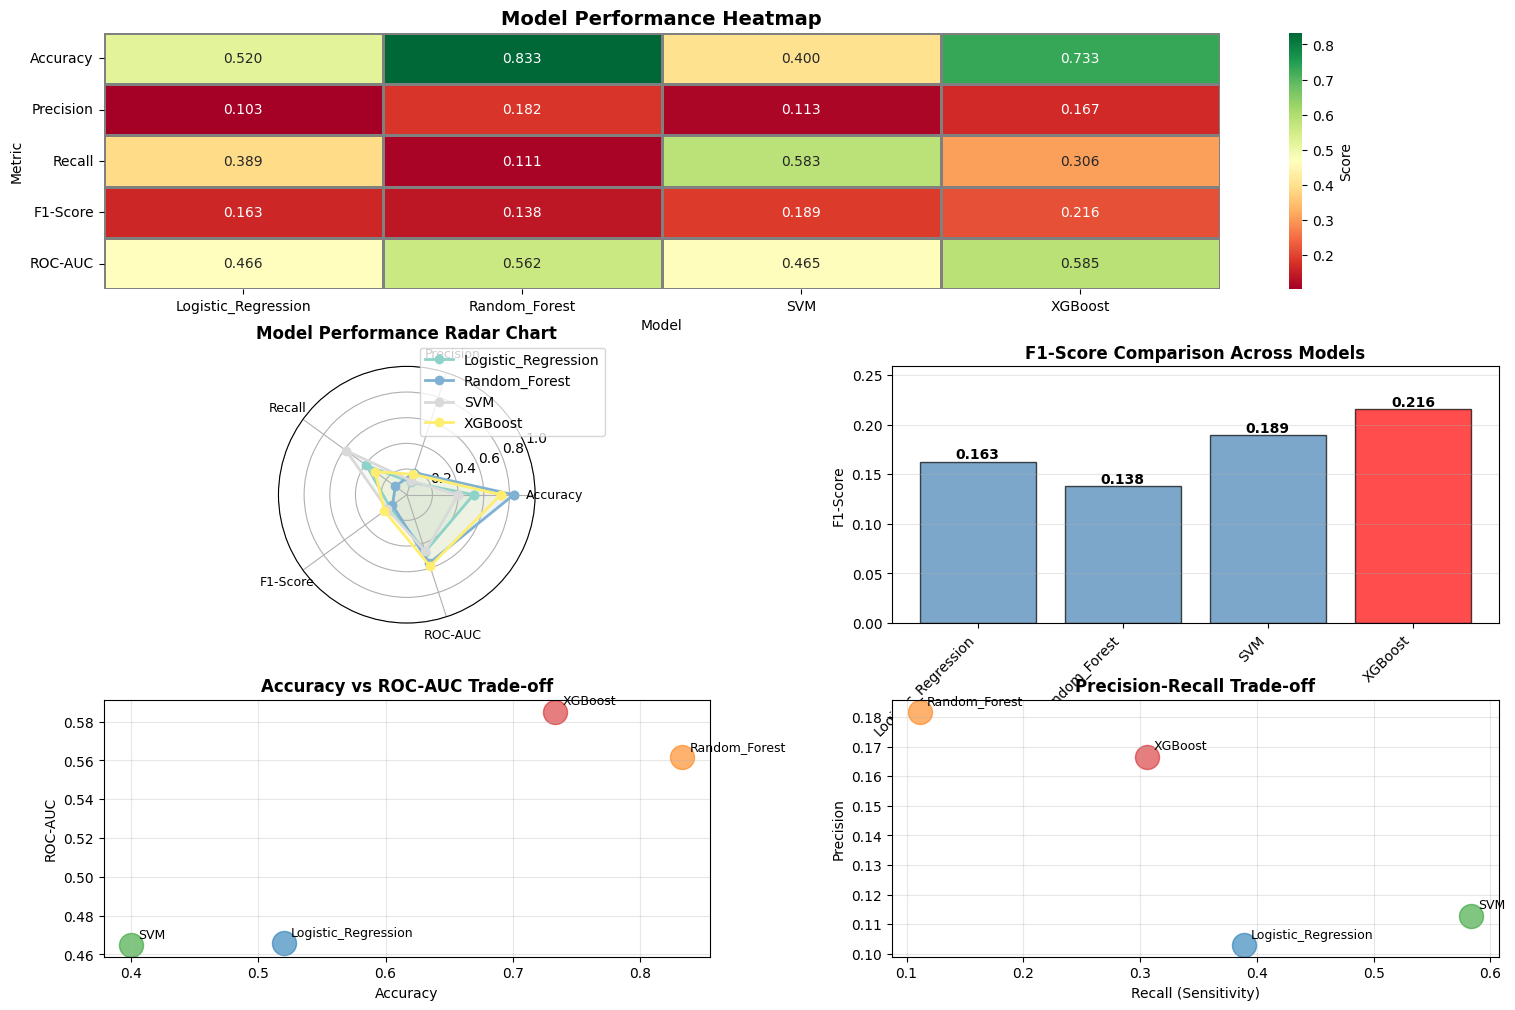

✓ Model performance comparison saved as 'model_performance_comparison.png'


In [ ]:
# Model Performance Heatmap & Advanced Comparisons
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Model Performance Heatmap
ax1 = fig.add_subplot(gs[0, :])
heatmap_data = comparison_df_updated[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].T
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    ax=ax1,
    cbar_kws={"label": "Score"},
    linewidths=1,
    linecolor="gray",
)
ax1.set_title("Model Performance Heatmap", fontsize=14, fontweight="bold")
ax1.set_xlabel("Model")
ax1.set_ylabel("Metric")

# 2. Radar/Spider Chart for Model Comparison
from math import pi

ax2 = fig.add_subplot(gs[1, 0], projection="polar")
categories = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

colors = plt.cm.Set3(np.linspace(0, 1, len(results)))
for idx, (model_name, color) in enumerate(zip(results.keys(), colors)):
    values = [
        results[model_name]["accuracy"],
        results[model_name]["precision"],
        results[model_name]["recall"],
        results[model_name]["f1_score"],
        results[model_name]["roc_auc"],
    ]
    values += values[:1]
    ax2.plot(angles, values, "o-", linewidth=2, label=model_name, color=color)
    ax2.fill(angles, values, alpha=0.15, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=9)
ax2.set_ylim(0, 1)
ax2.set_title("Model Performance Radar Chart", fontsize=12, fontweight="bold", pad=20)
ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax2.grid(True)

# 3. F1-Score Comparison Bar Chart
ax3 = fig.add_subplot(gs[1, 1])
f1_scores = [results[name]["f1_score"] for name in results.keys()]
colors_bar = ["red" if f1 == max(f1_scores) else "steelblue" for f1 in f1_scores]
bars = ax3.bar(
    results.keys(), f1_scores, color=colors_bar, alpha=0.7, edgecolor="black"
)
ax3.set_ylabel("F1-Score")
ax3.set_title("F1-Score Comparison Across Models", fontsize=12, fontweight="bold")
ax3.set_ylim(0, max(f1_scores) * 1.2)
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax3.grid(alpha=0.3, axis="y")
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 4. Accuracy vs ROC-AUC Scatter
ax4 = fig.add_subplot(gs[2, 0])
for idx, model_name in enumerate(results.keys()):
    ax4.scatter(
        results[model_name]["accuracy"],
        results[model_name]["roc_auc"],
        s=300,
        alpha=0.6,
        label=model_name,
    )
    ax4.annotate(
        model_name,
        (results[model_name]["accuracy"], results[model_name]["roc_auc"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )
ax4.set_xlabel("Accuracy")
ax4.set_ylabel("ROC-AUC")
ax4.set_title("Accuracy vs ROC-AUC Trade-off", fontsize=12, fontweight="bold")
ax4.grid(alpha=0.3)

# 5. Precision-Recall Trade-off
ax5 = fig.add_subplot(gs[2, 1])
for idx, model_name in enumerate(results.keys()):
    ax5.scatter(
        results[model_name]["recall"],
        results[model_name]["precision"],
        s=300,
        alpha=0.6,
        label=model_name,
    )
    ax5.annotate(
        model_name,
        (results[model_name]["recall"], results[model_name]["precision"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )
ax5.set_xlabel("Recall (Sensitivity)")
ax5.set_ylabel("Precision")
ax5.set_title("Precision-Recall Trade-off", fontsize=12, fontweight="bold")
ax5.grid(alpha=0.3)

plt.savefig("model_performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Model performance comparison saved as 'model_performance_comparison.png'")

### Correlation & Prediction Error Analysis


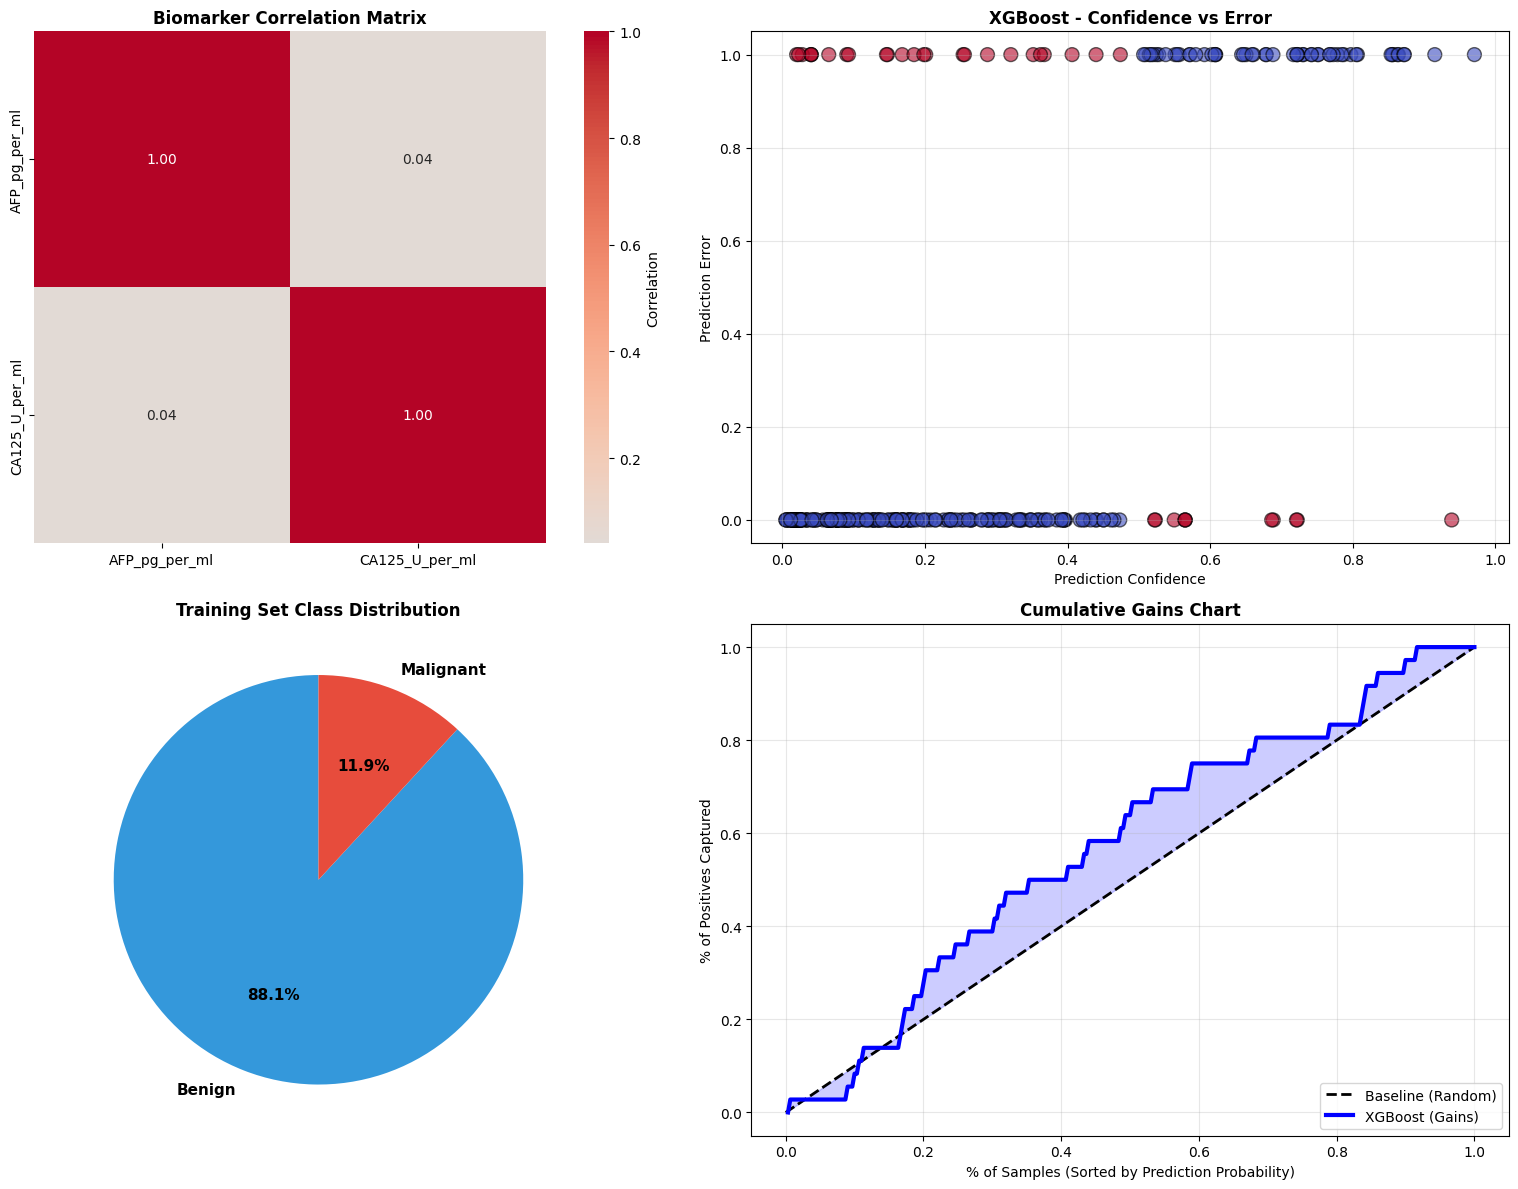

✓ Correlation and error analysis saved as 'correlation_error_analysis.png'


In [ ]:
# Correlation Matrix & Prediction Error Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation Matrix Heatmap
corr_matrix = pd.DataFrame(X_log, columns=feature_columns).corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0, 0],
    cbar_kws={"label": "Correlation"},
    square=True,
)
axes[0, 0].set_title("Biomarker Correlation Matrix", fontsize=12, fontweight="bold")

# 2. Prediction Error Analysis
errors = np.abs(y_val.values - results[best_model_name]["y_pred"])
axes[0, 1].scatter(
    results[best_model_name]["y_pred_proba"],
    errors,
    c=y_val,
    cmap="coolwarm",
    s=100,
    alpha=0.6,
    edgecolors="k",
)
axes[0, 1].set_xlabel("Prediction Confidence")
axes[0, 1].set_ylabel("Prediction Error")
axes[0, 1].set_title(
    f"{best_model_name} - Confidence vs Error", fontsize=12, fontweight="bold"
)
axes[0, 1].grid(alpha=0.3)

# 3. Class Imbalance Visualization
class_counts = [len(y_train[y_train == 0]), len(y_train[y_train == 1])]
colors_imbalance = ["#3498db", "#e74c3c"]
wedges, texts, autotexts = axes[1, 0].pie(
    class_counts,
    labels=["Benign", "Malignant"],
    autopct="%1.1f%%",
    colors=colors_imbalance,
    startangle=90,
    textprops={"fontsize": 11, "weight": "bold"},
)
axes[1, 0].set_title("Training Set Class Distribution", fontsize=12, fontweight="bold")

# 4. Cumulative Gains Chart
sorted_indices = np.argsort(results[best_model_name]["y_pred_proba"])[::-1]
sorted_y = y_val.values[sorted_indices]
cumsum_positives = np.cumsum(sorted_y)
cumsum_all = np.arange(1, len(sorted_y) + 1)
gains = cumsum_positives / cumsum_positives[-1]
percentiles = cumsum_all / len(cumsum_all)

axes[1, 1].plot([0, 1], [0, 1], "k--", label="Baseline (Random)", linewidth=2)
axes[1, 1].plot(
    percentiles, gains, "b-", label=f"{best_model_name} (Gains)", linewidth=3
)
axes[1, 1].fill_between(percentiles, percentiles, gains, alpha=0.2, color="blue")
axes[1, 1].set_xlabel("% of Samples (Sorted by Prediction Probability)")
axes[1, 1].set_ylabel("% of Positives Captured")
axes[1, 1].set_title("Cumulative Gains Chart", fontsize=12, fontweight="bold")
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("correlation_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Correlation and error analysis saved as 'correlation_error_analysis.png'")

### Calibration Curves & Risk Distribution


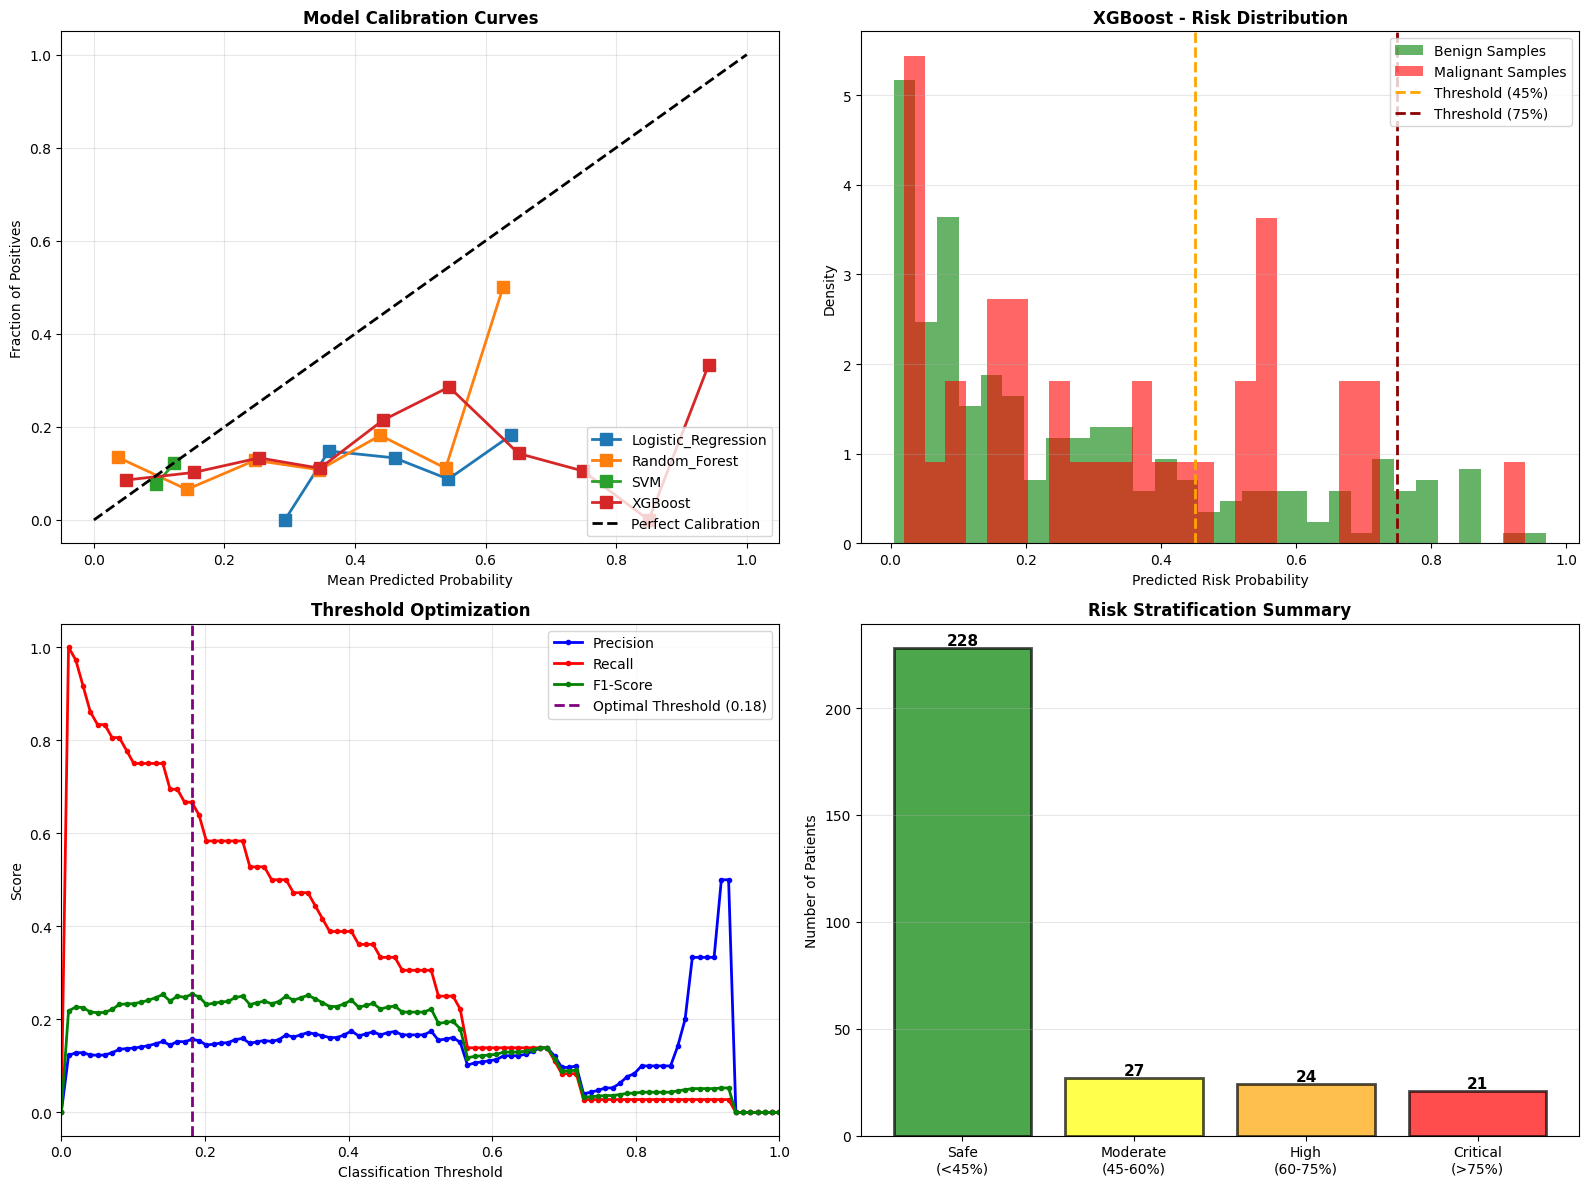

✓ Calibration and risk analysis saved as 'calibration_risk_analysis.png'


In [ ]:
# Calibration Curves & Detailed Risk Analysis
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Calibration Curves for all models
for model_name in results.keys():
    if results[model_name]["y_pred_proba"] is not None:
        frac_pos, mean_pred = calibration_curve(
            y_val, results[model_name]["y_pred_proba"], n_bins=10
        )
        axes[0, 0].plot(
            mean_pred, frac_pos, "s-", label=model_name, linewidth=2, markersize=8
        )

axes[0, 0].plot([0, 1], [0, 1], "k--", label="Perfect Calibration", linewidth=2)
axes[0, 0].set_xlabel("Mean Predicted Probability")
axes[0, 0].set_ylabel("Fraction of Positives")
axes[0, 0].set_title("Model Calibration Curves", fontsize=12, fontweight="bold")
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim([-0.05, 1.05])
axes[0, 0].set_ylim([-0.05, 1.05])

# 2. Risk Distribution by True Label
axes[0, 1].hist(
    results[best_model_name]["y_pred_proba"][y_val == 0],
    bins=30,
    alpha=0.6,
    label="Benign Samples",
    color="green",
    density=True,
)
axes[0, 1].hist(
    results[best_model_name]["y_pred_proba"][y_val == 1],
    bins=30,
    alpha=0.6,
    label="Malignant Samples",
    color="red",
    density=True,
)
axes[0, 1].axvline(
    0.45, color="orange", linestyle="--", linewidth=2, label="Threshold (45%)"
)
axes[0, 1].axvline(
    0.75, color="darkred", linestyle="--", linewidth=2, label="Threshold (75%)"
)
axes[0, 1].set_xlabel("Predicted Risk Probability")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title(
    f"{best_model_name} - Risk Distribution", fontsize=12, fontweight="bold"
)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis="y")

# 3. Threshold Optimization Curve
thresholds = np.linspace(0, 1, 100)
precisions, recalls, f1_scores_threshold = [], [], []

for threshold in thresholds:
    y_pred_threshold = (results[best_model_name]["y_pred_proba"] >= threshold).astype(
        int
    )
    if len(np.unique(y_pred_threshold)) > 1:
        prec = precision_score(y_val, y_pred_threshold, zero_division=0)
        rec = recall_score(y_val, y_pred_threshold, zero_division=0)
        f1 = f1_score(y_val, y_pred_threshold, zero_division=0)
    else:
        prec, rec, f1 = 0, 0, 0
    precisions.append(prec)
    recalls.append(rec)
    f1_scores_threshold.append(f1)

axes[1, 0].plot(
    thresholds, precisions, "b-", linewidth=2, label="Precision", marker="."
)
axes[1, 0].plot(thresholds, recalls, "r-", linewidth=2, label="Recall", marker=".")
axes[1, 0].plot(
    thresholds, f1_scores_threshold, "g-", linewidth=2, label="F1-Score", marker="."
)
best_threshold_idx = np.argmax(f1_scores_threshold)
axes[1, 0].axvline(
    thresholds[best_threshold_idx],
    color="purple",
    linestyle="--",
    linewidth=2,
    label=f"Optimal Threshold ({thresholds[best_threshold_idx]:.2f})",
)
axes[1, 0].set_xlabel("Classification Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Threshold Optimization", fontsize=12, fontweight="bold")
axes[1, 0].legend(loc="best")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlim([0, 1])

# 4. Risk Stratification Summary
risk_categories = [
    "Safe\n(<45%)",
    "Moderate\n(45-60%)",
    "High\n(60-75%)",
    "Critical\n(>75%)",
]
risk_counts = [
    (results[best_model_name]["y_pred_proba"] < 0.45).sum(),
    (
        (results[best_model_name]["y_pred_proba"] >= 0.45)
        & (results[best_model_name]["y_pred_proba"] < 0.60)
    ).sum(),
    (
        (results[best_model_name]["y_pred_proba"] >= 0.60)
        & (results[best_model_name]["y_pred_proba"] <= 0.75)
    ).sum(),
    (results[best_model_name]["y_pred_proba"] > 0.75).sum(),
]
colors_risk = ["green", "yellow", "orange", "red"]
bars = axes[1, 1].bar(
    risk_categories,
    risk_counts,
    color=colors_risk,
    alpha=0.7,
    edgecolor="black",
    linewidth=2,
)
for bar, count in zip(bars, risk_counts):
    height = bar.get_height()
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )
axes[1, 1].set_ylabel("Number of Patients")
axes[1, 1].set_title("Risk Stratification Summary", fontsize=12, fontweight="bold")
axes[1, 1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("calibration_risk_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Calibration and risk analysis saved as 'calibration_risk_analysis.png'")

### Cross-Validation on Best Model

In [ ]:
# COMPLETE FIX - Run this to restore everything and run CV
print("COMPLETE DATA RESTORATION AND CV")
print("=" * 60)

# 1. Restore y from original data
if "df_clean" in locals():
    y = df_clean["high_risk"].copy()
else:
    # Reload if needed
    df = pd.read_excel("Raw_data_dpv.xlsx", sheet_name="Target_Concentrations")
    feature_columns = ["AFP_pg_per_ml", "CA125_U_per_ml"]
    PSA_CUTOFF = 4000
    df["high_risk"] = (df["PSA_pg_per_ml"] > PSA_CUTOFF).astype(int)
    df_clean = df[feature_columns + ["high_risk"]].dropna()
    y = df_clean["high_risk"].copy()

# 2. Ensure y is pandas Series
print(f"y restored: type={type(y)}, shape={y.shape}")

# 3. Run cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_model = trained_models[best_model_name]

cv_scores = cross_val_score(best_model, X_scaled, y, cv=cv, scoring="f1")

print(f"\n✅ 5-Fold Cross-Validation for {best_model_name}:")
print(f"  Individual F1-scores: {cv_scores}")
print(f"  Mean F1-score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

COMPLETE DATA RESTORATION AND CV
y restored: type=<class 'pandas.core.series.Series'>, shape=(1000,)

✅ 5-Fold Cross-Validation for XGBoost:
  Individual F1-scores: [0.19672131 0.19230769 0.17857143 0.16393443 0.16393443]
  Mean F1-score: 0.1791 (+/- 0.0275)


### Save All Results to Files

In [ ]:
# Save comparison table (updated with GNN)
comparison_df.to_csv("../results/model_comparison.csv")
print("✓ model_comparison.csv saved")

# Create GNN-inclusive comparison
comparison_df_all = pd.DataFrame(
    {
        name: {
            "Accuracy": results[name]["accuracy"],
            "Precision": results[name]["precision"],
            "Recall": results[name]["recall"],
            "F1-Score": results[name]["f1_score"],
            "ROC-AUC": results[name]["roc_auc"],
        }
        for name in results
    }
).T
comparison_df_all.to_csv("../results/model_comparison_all_models.csv")
print("✓ model_comparison_all_models.csv saved (includes GNN)")

# Save detailed classification reports
with open("../results/classification_reports.txt", "w") as f:
    f.write("=" * 70 + "\n")
    f.write("CLASSIFICATION REPORTS (Threshold = 0.5)\n")
    f.write("=" * 70 + "\n\n")

    for name in results:
        f.write(f"\n{'='*50}\n")
        f.write(f"{name}\n")
        f.write(f"{'='*50}\n")
        y_pred = results[name]["y_pred"]
        report = classification_report(
            y_val, y_pred, target_names=["Low Risk", "High Risk"]
        )
        f.write(report)
        f.write(f"\nConfusion Matrix:\n{results[name]['confusion_matrix']}\n")
        f.write(f"\nROC-AUC: {results[name]['roc_auc']:.4f}\n")
print("✓ classification_reports.txt saved")

# Save predictions
val_predictions = pd.DataFrame(
    {
        "true_label": y_val.values,
        **{f"{name}_predicted": results[name]["y_pred"] for name in results},
        **{
            f"{name}_probability": results[name]["y_pred_proba"]
            for name in results
            if results[name]["y_pred_proba"] is not None
        },
    }
)
val_predictions.to_csv("../results/validation_predictions.csv", index=False)
print("✓ validation_predictions.csv saved")

# Save summary statistics
summary = {
    "total_samples": len(df),
    "samples_after_cleaning": len(df_clean),
    "features_used": feature_columns,
    "target_definition": f"PSA > {PSA_CUTOFF} pg/mL",
    "train_size": len(X_train),
    "validation_size": len(X_val),
    "class_0_percent": (y == 0).sum() / len(y) * 100,
    "class_1_percent": (y == 1).sum() / len(y) * 100,
    "best_model": best_model_name,
    "best_model_accuracy": comparison_df.loc[best_model_name, "Accuracy"],
    "best_model_f1": comparison_df.loc[best_model_name, "F1-Score"],
    "best_model_auc": comparison_df.loc[best_model_name, "ROC-AUC"],
    "cv_mean_f1": cv_scores.mean(),
    "cv_std_f1": cv_scores.std(),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("../results/analysis_summary.csv", index=False)
print("✓ analysis_summary.csv saved")

# Save GNN-specific results
if "GNN" in results:
    gnn_summary = {
        "Model": "GNN",
        "Accuracy": results["GNN"]["accuracy"],
        "Precision": results["GNN"]["precision"],
        "Recall": results["GNN"]["recall"],
        "F1-Score": results["GNN"]["f1_score"],
        "ROC-AUC": results["GNN"]["roc_auc"],
    }
    gnn_df = pd.DataFrame([gnn_summary])
    gnn_df.to_csv("../results/gnn_results.csv", index=False)
    print("✓ gnn_results.csv saved")

print("\n✅ All results saved successfully!")

✓ model_comparison.csv saved
✓ model_comparison_all_models.csv saved (includes GNN)
✓ classification_reports.txt saved
✓ validation_predictions.csv saved
✓ analysis_summary.csv saved

✅ All results saved successfully!
